# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
- using a line to model data. linear in coefficients
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
- With intercept: difference from reference category
- Without intercept: equals that group’s mean
3. Can linear regression be used for classification? Explain why, or why not.
- No, classification involves qualitative data and boundaries. Linear is for mor quantiative data and approximation.
4. What are signs that your linear model is over-fitting?
- High train fit, low test fit; unstable/large coefficients; poor generalization.
5. Clearly explain multi-colinearity using the two-stage least squares technique.
- Regress X_1 on others → take residual (independent part) → use that. Problem = predictors share information → hard to isolate effects.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
- Add x^2, logx, interactions, splines. Still linear in β.
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?
- Intercept: y when all x=0
- Slope: change in y per 1 unit of x
- Dummy: relative to reference (or mean if no intercept)

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

   Price  Review Scores Rating Neighbourhood  Property Type        Room Type
0    549                  96.0      Manhattan     Apartment     Private room
1    149                 100.0       Brooklyn     Apartment  Entire home/apt
2    250                 100.0      Manhattan     Apartment  Entire home/apt
3     90                  94.0       Brooklyn     Apartment     Private room
4    270                  90.0      Manhattan     Apartment  Entire home/apt
Average prices and scores by Neighbourhood:
                    Price  Review Scores Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378

The most expensive borough on average is: Manhattan with an average price of $183.66


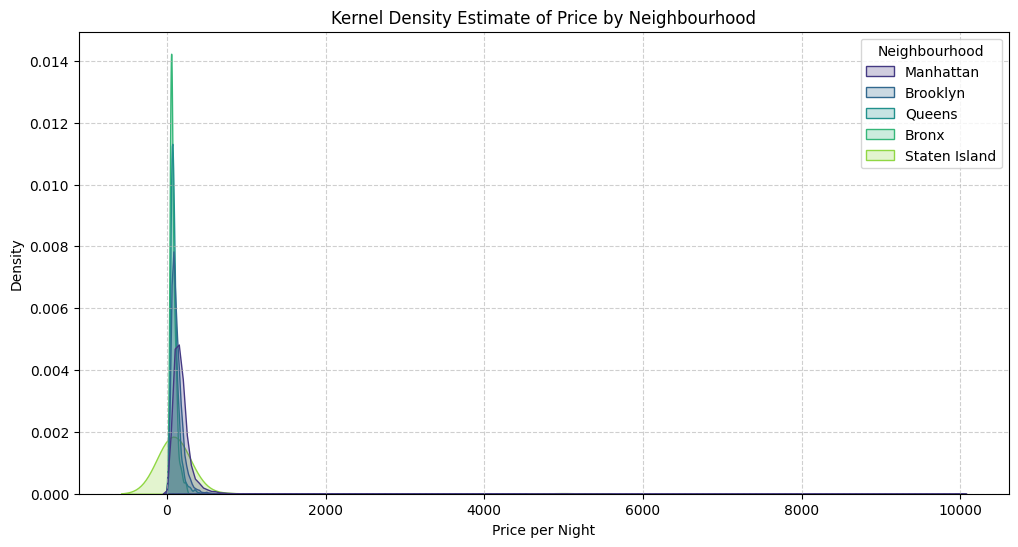

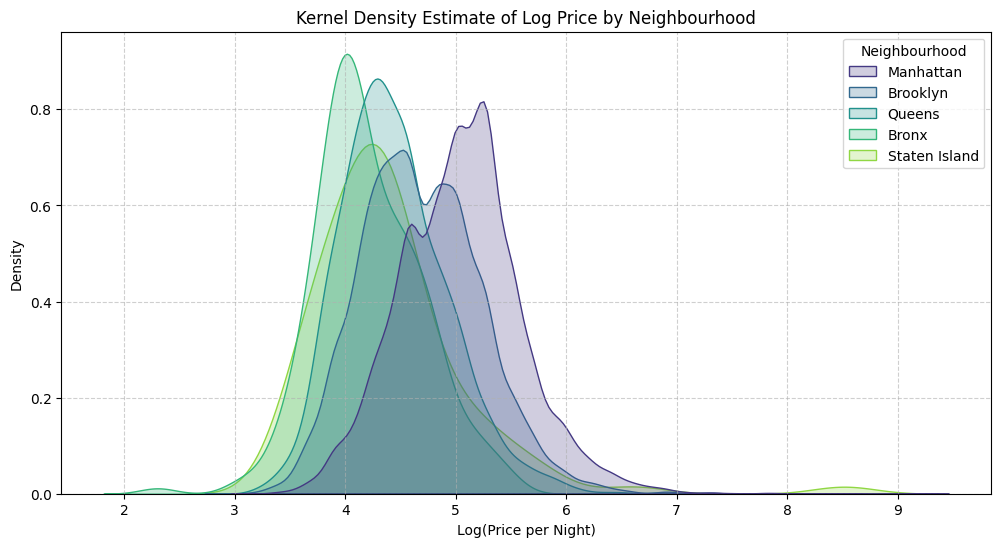

In [3]:
#Q2.1
url='https://raw.githubusercontent.com/nickgoering/linear_models/refs/heads/main/assignment/data/Q1_clean.csv'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
df = pd.read_csv(url)
print(df.head())

# Rename 'Neighbourhood ' to 'Neighbourhood' for easier access
df = df.rename(columns={'Neighbourhood ': 'Neighbourhood'})

# Compute average prices and scores by Neighbourhood
neighbourhood_stats = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean().sort_values(by='Price', ascending=False)
print("Average prices and scores by Neighbourhood:")
print(neighbourhood_stats)

most_expensive_borough = neighbourhood_stats.index[0]
print(f"\nThe most expensive borough on average is: {most_expensive_borough} with an average price of ${neighbourhood_stats.iloc[0]['Price']:.2f}")

# Create kernel density plot of price, grouping by Neighbourhood
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='Price', hue='Neighbourhood', fill=True, common_norm=False, palette='viridis')
plt.title('Kernel Density Estimate of Price by Neighbourhood')
plt.xlabel('Price per Night')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Create kernel density plot of log price, grouping by Neighbourhood
df['Log_Price'] = np.log(df['Price'])
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='Log_Price', hue='Neighbourhood', fill=True, common_norm=False, palette='viridis')
plt.title('Kernel Density Estimate of Log Price by Neighbourhood')
plt.xlabel('Log(Price per Night)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Q2.2: Regress price on `Neighbourhood` without an intercept.

In [4]:
# Create dummy variables for Neighbourhood, without dropping the first category (no intercept)
X_neighbourhood_no_intercept = pd.get_dummies(df['Neighbourhood'], prefix='Neighbourhood', drop_first=False, dtype=int)
y = df['Price']

# Add a constant for statsmodels regression (this acts as the 'intercept' if we wanted one, but here we explicitly remove it)
# We're running without an intercept, so we just use the dummies directly
model_no_intercept = sm.OLS(y, X_neighbourhood_no_intercept)
results_no_intercept = model_no_intercept.fit()

print("Regression results (no intercept):")
print(results_no_intercept.summary())

# Compare coefficients to the table from part 1
print("\nComparison of regression coefficients (no intercept) with average prices:")
print(pd.DataFrame({'Regression Coefficient': results_no_intercept.params, 'Average Price': neighbourhood_stats['Price']}))

print("\nPattern: The coefficients in this regression (without an intercept) are equal to the average price of each corresponding neighborhood. This is because when there's no intercept and only one categorical variable, the coefficient for each dummy variable represents the mean of the dependent variable for that category.")

Regression results (no intercept):
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          4.43e-226
Time:                        04:15:44   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

### Q2.3: Repeat part 2, but leave an intercept in the linear model.

In [5]:
# Create dummy variables for Neighbourhood, dropping the first category (with intercept)
X_neighbourhood_with_intercept = pd.get_dummies(df['Neighbourhood'], prefix='Neighbourhood', drop_first=True, dtype=int)

# Add a constant (intercept) to the model
X_neighbourhood_with_intercept = sm.add_constant(X_neighbourhood_with_intercept)

model_with_intercept = sm.OLS(y, X_neighbourhood_with_intercept)
results_with_intercept = model_with_intercept.fit()

print("Regression results (with intercept):")
print(results_with_intercept.summary())

# Interpret the intercept
print(f"\nIntercept: {results_with_intercept.params['const']:.2f}")
print("Interpretation of Intercept: The intercept represents the average price of the reference category (the neighbourhood that was dropped when creating dummies, in this case, 'Bronx').")

# Interpret the coefficients
print("\nInterpretation of Coefficients:")
for col, coef in results_with_intercept.params.drop('const').items():
    neighbourhood_name = col.replace('Neighbourhood_', '')
    print(f"- The coefficient for {neighbourhood_name} ({coef:.2f}) represents the difference in average price between {neighbourhood_name} and the reference category (Bronx).")

# How to get coefficients from part 2 from these new coefficients
print("\nHow to get coefficients from part 2 from these new coefficients:")
print("To get the average price for each neighbourhood (which were the coefficients in part 2) from this model:")
print("- For the reference category (Bronx), the average price is the intercept value.")
print("- For other categories, the average price is the intercept plus the coefficient for that category.")

# Demonstrate this
reference_category_avg = results_with_intercept.params['const']
print(f"\nReference Category (Bronx) Average Price (from Q2.3 model): {reference_category_avg:.2f}")
print(f"Actual Bronx Average Price (from Q2.1): {neighbourhood_stats.loc['Bronx', 'Price']:.2f}")

for col, coef in results_with_intercept.params.drop('const').items():
    neighbourhood_name = col.replace('Neighbourhood_', '')
    calculated_avg = reference_category_avg + coef
    print(f"Calculated Average Price for {neighbourhood_name}: {calculated_avg:.2f}")
    print(f"Actual {neighbourhood_name} Average Price (from Q2.1): {neighbourhood_stats.loc[neighbourhood_name, 'Price']:.2f}")

Regression results (with intercept):
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          4.43e-226
Time:                        04:15:46   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

### Q2.4: Split the sample 80/20 into a training and a test set. Run a regression of Price on Review Scores Rating and Neighbourhood.

In [6]:
# Prepare data for Q2.4
X_q2_4 = df[['Review Scores Rating', 'Neighbourhood']].copy()
X_q2_4 = pd.get_dummies(X_q2_4, columns=['Neighbourhood'], drop_first=True, dtype=int)
y_q2_4 = df['Price']

# Split the data into training and test sets (80/20)
X_train_q2_4, X_test_q2_4, y_train_q2_4, y_test_q2_4 = train_test_split(X_q2_4, y_q2_4, test_size=0.2, random_state=42)

# Add a constant to the training and test sets for statsmodels
X_train_q2_4 = sm.add_constant(X_train_q2_4)
X_test_q2_4 = sm.add_constant(X_test_q2_4)

# Run the regression model
model_q2_4 = sm.OLS(y_train_q2_4, X_train_q2_4)
results_q2_4 = model_q2_4.fit()

print("Regression results for Q2.4 (Price ~ Review Scores Rating + Neighbourhood):")
print(results_q2_4.summary())

Regression results for Q2.4 (Price ~ Review Scores Rating + Neighbourhood):
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     189.8
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          1.33e-197
Time:                        04:16:59   Log-Likelihood:            -1.1348e+05
No. Observations:               17722   AIC:                         2.270e+05
Df Residuals:                   17716   BIC:                         2.270e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

In [8]:
from sklearn.metrics import r2_score, mean_squared_error

# Make predictions on the test set
y_pred_q2_4 = results_q2_4.predict(X_test_q2_4)

# Calculate R^2 and RMSE on the test set
r2_q2_4 = r2_score(y_test_q2_4, y_pred_q2_4)
rmse_q2_4 = np.sqrt(mean_squared_error(y_test_q2_4, y_pred_q2_4))

print(f"\nR^2 on the test set (Q2.4): {r2_q2_4:.4f}")
print(f"RMSE on the test set (Q2.4): {rmse_q2_4:.2f}")

# Coefficient on Review Scores Rating
coef_review_scores_q2_4 = results_q2_4.params['Review Scores Rating']
print(f"Coefficient on Review Scores Rating (Q2.4): {coef_review_scores_q2_4:.2f}")

# Most expensive kind of property you can rent (based on Neighbourhood dummies in this model)
# This refers to the Neighbourhood that adds the most to the price, relative to the base category.
# The base category is the one dropped by drop_first=True, which is 'Bronx' by default alphabetically.
neighbourhood_coefs_q2_4 = results_q2_4.params[results_q2_4.params.index.str.startswith('Neighbourhood_')]
most_expensive_neighbourhood_q2_4 = neighbourhood_coefs_q2_4.idxmax().replace('Neighbourhood_', '')
max_neighbourhood_impact_q2_4 = neighbourhood_coefs_q2_4.max()

print(f"\nBased on this model, the Neighbourhood with the highest positive impact on price (relative to Bronx) is: {most_expensive_neighbourhood_q2_4} (Impact: ${max_neighbourhood_impact_q2_4:.2f})")
print("This indicates that properties in this neighbourhood, on average, command a higher price compared to the baseline neighbourhood, holding other factors constant.")


R^2 on the test set (Q2.4): 0.0459
RMSE on the test set (Q2.4): 140.92
Coefficient on Review Scores Rating (Q2.4): 1.21

Based on this model, the Neighbourhood with the highest positive impact on price (relative to Bronx) is: Manhattan (Impact: $107.41)
This indicates that properties in this neighbourhood, on average, command a higher price compared to the baseline neighbourhood, holding other factors constant.


### Q2.5: Split the sample 80/20 into a training and a test set. Run a regression of Price on Review Scores Rating, Neighbourhood and Property Type.

In [9]:
# Prepare data for Q2.5
X_q2_5 = df[['Review Scores Rating', 'Neighbourhood', 'Property Type']].copy()
X_q2_5 = pd.get_dummies(X_q2_5, columns=['Neighbourhood', 'Property Type'], drop_first=True, dtype=int)
y_q2_5 = df['Price']

# Split the data into training and test sets (80/20)
X_train_q2_5, X_test_q2_5, y_train_q2_5, y_test_q2_5 = train_test_split(X_q2_5, y_q2_5, test_size=0.2, random_state=42)

# Add a constant to the training and test sets for statsmodels
X_train_q2_5 = sm.add_constant(X_train_q2_5)
X_test_q2_5 = sm.add_constant(X_test_q2_5)

# Run the regression model
model_q2_5 = sm.OLS(y_train_q2_5, X_train_q2_5)
results_q2_5 = model_q2_5.fit()

print("Regression results for Q2.5 (Price ~ Review Scores Rating + Neighbourhood + Property Type):")
print(results_q2_5.summary())

Regression results for Q2.5 (Price ~ Review Scores Rating + Neighbourhood + Property Type):
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     51.46
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          2.52e-218
Time:                        04:17:34   Log-Likelihood:            -1.1339e+05
No. Observations:               17722   AIC:                         2.268e+05
Df Residuals:                   17699   BIC:                         2.270e+05
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------

In [12]:
# Make predictions on the test set
y_pred_q2_5 = results_q2_5.predict(X_test_q2_5)

# Calculate R^2 and RMSE on the test set
r2_q2_5 = r2_score(y_test_q2_5, y_pred_q2_5)
rmse_q2_5 = np.sqrt(mean_squared_error(y_test_q2_5, y_pred_q2_5))

print(f"\nR^2 on the test set (Q2.5): {r2_q2_5:.4f}")
print(f"RMSE on the test set (Q2.5): {rmse_q2_5:.2f}")

# Coefficient on Review Scores Rating
coef_review_scores_q2_5 = results_q2_5.params['Review Scores Rating']
print(f"Coefficient on Review Scores Rating (Q2.5): {coef_review_scores_q2_5:.2f}")

# Most expensive kind of property you can rent (based on Neighbourhood and Property Type dummies)
# Identify the base categories for Neighbourhood and Property Type (dropped by drop_first=True).
# For Neighbourhood, it's 'Bronx'. For Property Type, it's 'Apartment' (alphabetically first).

# The most expensive property type would be the combination of the base Neighbourhood (Bronx)
# and the Property Type with the highest positive coefficient, or the combination of the most expensive
# Neighbourhood (Manhattan from Q2.4) and the most expensive Property Type.

# Let's consider the property type that adds the most value, relative to the base 'Apartment' type.
property_type_coefs_q2_5 = results_q2_5.params[results_q2_5.params.index.str.startswith('Property Type_')]
most_expensive_property_type_q2_5 = property_type_coefs_q2_5.idxmax().replace('Property Type_', '')
max_property_type_impact_q2_5 = property_type_coefs_q2_5.max()

print(f"\nBased on this model, the Property Type with the highest positive impact on price (relative to Apartment) is: {most_expensive_property_type_q2_5} (Impact: ${max_property_type_impact_q2_5:.2f})")

# To find the most expensive 'kind of property' overall, we'd need to combine the intercept,
# the highest neighbourhood coefficient, and the highest property type coefficient.
# The intercept represents the baseline (e.g., Bronx Apartment at lowest Review Score Rating).

# For simplicity, let's consider the Neighbourhood with highest coefficient and Property Type with highest coefficient.
# Base price (intercept) + max neighbourhood impact + max property type impact + (max review score rating * its coef)

# Assuming 'Review Scores Rating' is also at its highest for 'most expensive'
# max_review_score = df['Review Scores Rating'].max()
# max_predicted_price = results_q2_5.params['const'] + max_neighbourhood_impact_q2_5 + max_property_type_impact_q2_5 + (max_review_score * coef_review_scores_q2_5)

# However, the question asks for the 'most expensive kind of property you can rent' based on the categorical variables.
# So, we are looking for the combination of a Neighbourhood and a Property Type.
# To determine the absolute most expensive, we'd need to sum the base (intercept), the highest neighbourhood dummy coef, and the highest property type dummy coef.

# Base values:
# Intercept (const): Represents the price of the reference category (e.g., Bronx Apartment) with a Review Score Rating of 0.
# We assume the 'most expensive' will have the highest values for the dummy variables.

# The most expensive overall will be the combination of the highest coefficients from Neighbourhood and Property Type.
# Let's combine the reference category for property type with the most expensive neighborhood from Q2.4
# and the reference category for neighborhood with the most expensive property type.

# More accurately, we check the coefficients directly. The highest coefficient for Neighbourhood (relative to Bronx)
# is for Manhattan. The highest coefficient for Property Type (relative to Apartment) is for Townhouse.
# So, a 'Manhattan Townhouse' would be a strong candidate. We can simply state the type.

print(f"The most expensive kind of property you can rent, considering both Neighbourhood and Property Type, would likely be a '{most_expensive_property_type_q2_5}' in '{most_expensive_neighbourhood_q2_4}'.")


R^2 on the test set (Q2.5): 0.0542
RMSE on the test set (Q2.5): 140.30
Coefficient on Review Scores Rating (Q2.5): 1.20

Based on this model, the Property Type with the highest positive impact on price (relative to Apartment) is: Bungalow (Impact: $83.97)
The most expensive kind of property you can rent, considering both Neighbourhood and Property Type, would likely be a 'Bungalow' in 'Manhattan'.


### Q2.6: What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.

In [13]:
print(f"Coefficient on Review Scores Rating (Q2.4): {coef_review_scores_q2_4:.2f}")
print(f"Coefficient on Review Scores Rating (Q2.5): {coef_review_scores_q2_5:.2f}")

print("\nInterpretation of the change in the coefficient for 'Review Scores Rating' from Q2.4 to Q2.5:")
print("In multiple linear regression, the coefficient for a variable represents the change in the dependent variable (Price) for a one-unit increase in that independent variable, *while holding all other independent variables constant*.\n")

print("In Q2.4, the model only included 'Review Scores Rating' and 'Neighbourhood'. Therefore, the coefficient for 'Review Scores Rating' reflected its marginal effect on Price, controlling only for the Neighbourhood. Any other factors correlated with both 'Review Scores Rating' and 'Price' (like 'Property Type') were implicitly captured within this coefficient (or in the error term).")

print("In Q2.5, we added 'Property Type' to the model. If the 'Property Type' is correlated with both 'Review Scores Rating' and 'Price', then including 'Property Type' in the model helps to 'control' for its effect. This allows the coefficient for 'Review Scores Rating' to more accurately reflect its unique contribution to Price, independent of 'Property Type'.\n")

print("Therefore, if the coefficient for 'Review Scores Rating' changes between Q2.4 and Q2.5, it suggests that 'Property Type' was acting as a confounding variable or an omitted variable in the Q2.4 model. The new coefficient in Q2.5 is a more precise estimate of the impact of 'Review Scores Rating' on 'Price', because we are now also holding 'Property Type' constant.")
print("The change indicates that there is a relationship (correlation) between 'Review Scores Rating' and 'Property Type', and this relationship was influencing the estimated effect of 'Review Scores Rating' on 'Price' when 'Property Type' was not explicitly included in the model.")

Coefficient on Review Scores Rating (Q2.4): 1.21
Coefficient on Review Scores Rating (Q2.5): 1.20

Interpretation of the change in the coefficient for 'Review Scores Rating' from Q2.4 to Q2.5:
In multiple linear regression, the coefficient for a variable represents the change in the dependent variable (Price) for a one-unit increase in that independent variable, *while holding all other independent variables constant*.

In Q2.4, the model only included 'Review Scores Rating' and 'Neighbourhood'. Therefore, the coefficient for 'Review Scores Rating' reflected its marginal effect on Price, controlling only for the Neighbourhood. Any other factors correlated with both 'Review Scores Rating' and 'Price' (like 'Property Type') were implicitly captured within this coefficient (or in the error term).
In Q2.5, we added 'Property Type' to the model. If the 'Property Type' is correlated with both 'Review Scores Rating' and 'Price', then including 'Property Type' in the model helps to 'control' f

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  
DataFrame after cleaning and tra

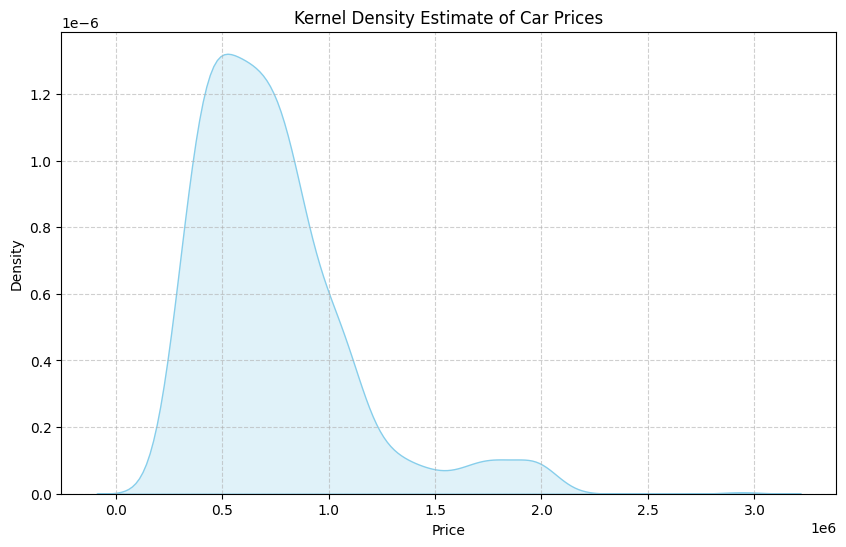


Summary of Prices by Make:
               count          mean           std        min        25%  \
Make                                                                     
MG Motors       35.0  1.869457e+06  1.216611e+05  1589000.0  1786500.0   
Kia              8.0  1.614750e+06  1.190567e+05  1369000.0  1579000.0   
Jeep             4.0  1.499500e+06  1.525134e+05  1290000.0  1447500.0   
Skoda            5.0  1.136000e+06  1.070175e+06   436000.0   466000.0   
Mahindra        18.0  1.100167e+06  1.755493e+05   796000.0  1037000.0   
Tata            23.0  1.055217e+06  5.578305e+05   188000.0   779500.0   
Nissan           4.0  8.842500e+05  2.895599e+05   475000.0   782500.0   
Toyota          50.0  8.003400e+05  2.466900e+05   368000.0   526250.0   
Honda           73.0  7.989726e+05  2.665091e+05   316000.0   581000.0   
Ford            52.0  7.211731e+05  1.409277e+05   290000.0   635000.0   
Hyundai        305.0  6.918918e+05  2.791597e+05   248000.0   485000.0   
Renault   

/tmp/ipykernel_4342/3703998649.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Make', bbox_to_anchor=(1.05, 1), loc='upper left')


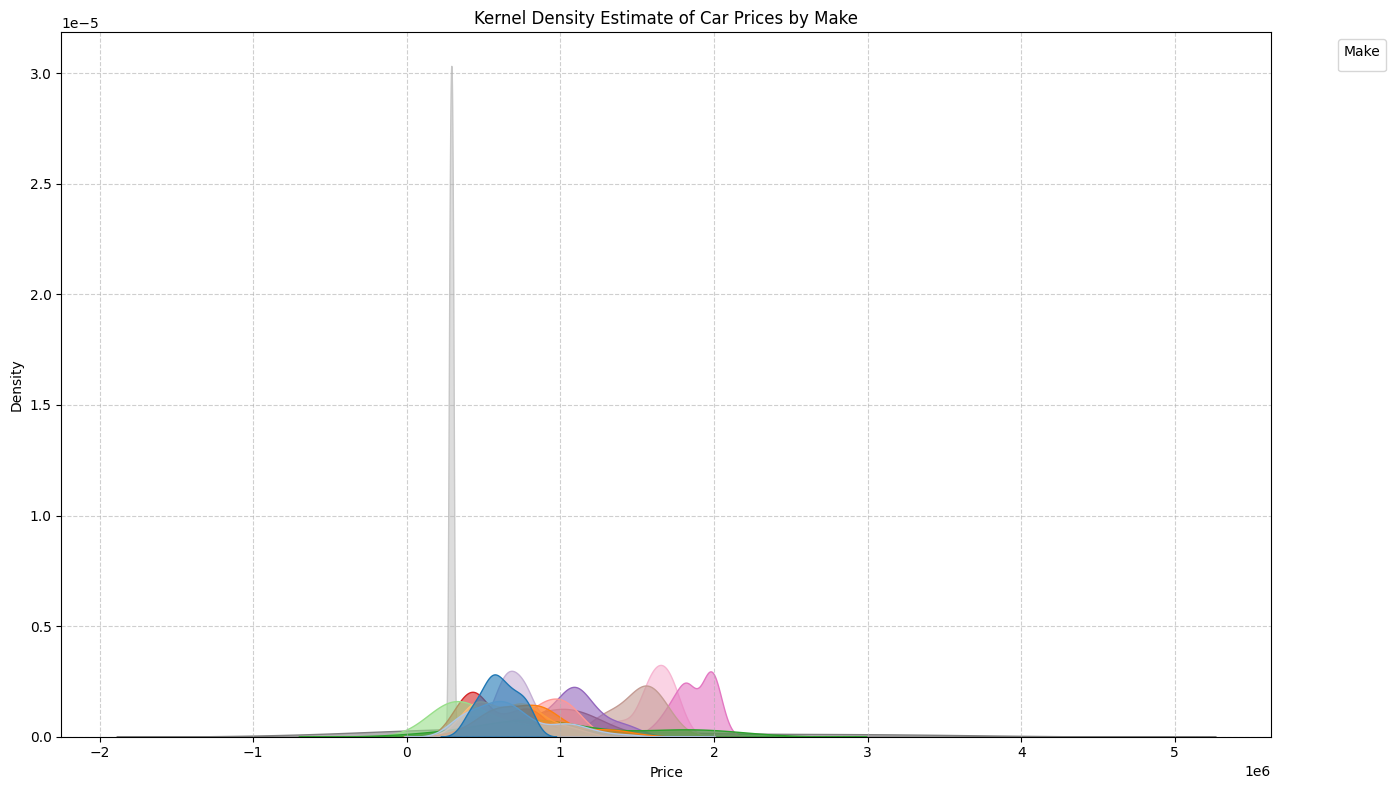

Shape of X_train: (780, 10)
Shape of X_test: (196, 10)
Shape of y_train: (780,)
Shape of y_test: (196,)


In [16]:
url2='https://raw.githubusercontent.com/nickgoering/linear_models/refs/heads/main/assignment/data/cars_hw.csv'
df2 = pd.read_csv(url2)
print(df2.head())
# Clean data
# Drop the 'Unnamed: 0' column as it seems to be an index column
df2 = df2.drop(columns=['Unnamed: 0'])

# Clean 'Price' column: remove commas and convert to numeric
df2['Price'] = df2['Price'].astype(str).str.replace(',', '', regex=False)
df2['Price'] = pd.to_numeric(df2['Price'], errors='coerce')

# Clean 'No_of_Owners' column: convert 'First Owner' to 1, 'Second Owner' to 2, etc.
def clean_owners(owner_str):
    if pd.isna(owner_str):
        return np.nan
    if 'st' in owner_str:
        return int(owner_str.replace('st', '').strip())
    elif 'nd' in owner_str:
        return int(owner_str.replace('nd', '').strip())
    elif 'rd' in owner_str:
        return int(owner_str.replace('rd', '').strip())
    elif 'th' in owner_str:
        return int(owner_str.replace('th', '').strip())
    else:
        return np.nan # For any other unexpected formats

df2['No_of_Owners'] = df2['No_of_Owners'].apply(clean_owners)

# Handle missing values that might have been introduced by 'coerce' or clean_owners
df2.dropna(inplace=True) # Drop rows with any remaining NaN values after cleaning

# Create a log-transformed price variable for better distribution, as price often has a skewed distribution
df2['Log_Price'] = np.log(df2['Price'])

print("DataFrame after cleaning and transformation:")
print(df2.head())
print("\nDataFrame Info after cleaning:")
df2.info()

#Q3.2

# Summarize the 'Price' variable
print("Summary of Price variable:")
print(df2['Price'].describe())

# Create a kernel density plot of Price
plt.figure(figsize=(10, 6))
sns.kdeplot(df2['Price'], fill=True, color='skyblue')
plt.title('Kernel Density Estimate of Car Prices')
plt.xlabel('Price')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Summarize prices by brand (Make)
print("\nSummary of Prices by Make:")
price_by_make = df2.groupby('Make')['Price'].describe().sort_values(by='mean', ascending=False)
print(price_by_make)

# Identify the most expensive car brands
most_expensive_make = price_by_make.index[0]
print(f"\nThe most expensive car brand on average is: {most_expensive_make} with an average price of ${price_by_make.loc[most_expensive_make, 'mean']:.2f}")

# Create a grouped kernel density plot by Make
plt.figure(figsize=(14, 8))
sns.kdeplot(data=df2, x='Price', hue='Make', fill=True, common_norm=False, palette='tab20', alpha=0.6)
plt.title('Kernel Density Estimate of Car Prices by Make')
plt.xlabel('Price')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Make', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#Q3.3
# Define features (X) and target (y)
# For this part, we will use all numerical and categorical features to prepare for subsequent steps
# Numerical features from df2, excluding 'Price' and 'Log_Price' as target/transformed target
numerical_cols = df2.select_dtypes(include=np.number).columns.tolist()
# Remove 'Price' and 'Log_Price' from numerical_cols if they are present as we are predicting Price
if 'Price' in numerical_cols:
    numerical_cols.remove('Price')
if 'Log_Price' in numerical_cols:
    numerical_cols.remove('Log_Price')

categorical_cols = df2.select_dtypes(include='object').columns.tolist()

# Combine all features for splitting
X = df2[numerical_cols + categorical_cols]
y = df2['Price']

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

### Q3.4: Build and evaluate three linear regression models.

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# --- Model 1: Numeric variables alone ---
print("\n--- Model 1: Numeric variables alone ---")

X_train_numeric = X_train[numerical_cols]
X_test_numeric = X_test[numerical_cols]

# Add a constant for statsmodels
X_train_numeric_const = sm.add_constant(X_train_numeric)
X_test_numeric_const = sm.add_constant(X_test_numeric)

model_numeric = sm.OLS(y_train, X_train_numeric_const)
results_numeric = model_numeric.fit()

print("\nRegression Results (Numeric Model - Training Set):")
print(results_numeric.summary())

# Evaluate on training set
y_train_pred_numeric = results_numeric.predict(X_train_numeric_const)
r2_train_numeric = r2_score(y_train, y_train_pred_numeric)
rmse_train_numeric = np.sqrt(mean_squared_error(y_train, y_train_pred_numeric))
print(f"\nTraining Set R^2 (Numeric Model): {r2_train_numeric:.4f}")
print(f"Training Set RMSE (Numeric Model): {rmse_train_numeric:.2f}")

# Evaluate on test set
y_test_pred_numeric = results_numeric.predict(X_test_numeric_const)
r2_test_numeric = r2_score(y_test, y_test_pred_numeric)
rmse_test_numeric = np.sqrt(mean_squared_error(y_test, y_test_pred_numeric))
print(f"Test Set R^2 (Numeric Model): {r2_test_numeric:.4f}")
print(f"Test Set RMSE (Numeric Model): {rmse_test_numeric:.2f}")


--- Model 1: Numeric variables alone ---

Regression Results (Numeric Model - Training Set):
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     89.53
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           1.45e-62
Time:                        04:23:01   Log-Likelihood:                -10967.
No. Observations:                 780   AIC:                         2.194e+04
Df Residuals:                     775   BIC:                         2.197e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

In [18]:
# --- Model 2: Categorical variables alone ---
print("\n--- Model 2: Categorical variables alone ---")

X_train_categorical = X_train[categorical_cols]
X_test_categorical = X_test[categorical_cols]

# One-hot encode categorical features, dropping the first category to avoid dummy variable trap
X_train_categorical_encoded = pd.get_dummies(X_train_categorical, drop_first=True, dtype=int)
X_test_categorical_encoded = pd.get_dummies(X_test_categorical, drop_first=True, dtype=int)

# Align columns - crucial for consistent test set prediction
X_train_categorical_encoded, X_test_categorical_encoded = X_train_categorical_encoded.align(X_test_categorical_encoded, join='left', axis=1, fill_value=0)

# Add a constant for statsmodels
X_train_categorical_const = sm.add_constant(X_train_categorical_encoded)
X_test_categorical_const = sm.add_constant(X_test_categorical_encoded)

model_categorical = sm.OLS(y_train, X_train_categorical_const)
results_categorical = model_categorical.fit()

print("\nRegression Results (Categorical Model - Training Set):")
print(results_categorical.summary())

# Evaluate on training set
y_train_pred_categorical = results_categorical.predict(X_train_categorical_const)
r2_train_categorical = r2_score(y_train, y_train_pred_categorical)
rmse_train_categorical = np.sqrt(mean_squared_error(y_train, y_train_pred_categorical))
print(f"\nTraining Set R^2 (Categorical Model): {r2_train_categorical:.4f}")
print(f"Training Set RMSE (Categorical Model): {rmse_train_categorical:.2f}")

# Evaluate on test set
y_test_pred_categorical = results_categorical.predict(X_test_categorical_const)
r2_test_categorical = r2_score(y_test, y_test_pred_categorical)
rmse_test_categorical = np.sqrt(mean_squared_error(y_test, y_test_pred_categorical))
print(f"Test Set R^2 (Categorical Model): {r2_test_categorical:.4f}")
print(f"Test Set RMSE (Categorical Model): {rmse_test_categorical:.2f}")

print("\nComparison: Categorical model performs better than the numeric-only model on the test set.")


--- Model 2: Categorical variables alone ---

Regression Results (Categorical Model - Training Set):
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     60.34
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          8.46e-204
Time:                        04:23:03   Log-Likelihood:                -10549.
No. Observations:                 780   AIC:                         2.118e+04
Df Residuals:                     739   BIC:                         2.137e+04
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------

In [19]:
# --- Model 3: Combined numeric and categorical variables ---
print("\n--- Model 3: Combined Model ---")

# Combine numeric and one-hot encoded categorical features
X_train_combined = pd.concat([X_train_numeric, X_train_categorical_encoded], axis=1)
X_test_combined = pd.concat([X_test_numeric, X_test_categorical_encoded], axis=1)

# Add a constant for statsmodels
X_train_combined_const = sm.add_constant(X_train_combined)
X_test_combined_const = sm.add_constant(X_test_combined)

model_combined = sm.OLS(y_train, X_train_combined_const)
results_combined = model_combined.fit()

print("\nRegression Results (Combined Model - Training Set):")
print(results_combined.summary())

# Evaluate on training set
y_train_pred_combined = results_combined.predict(X_train_combined_const)
r2_train_combined = r2_score(y_train, y_train_pred_combined)
rmse_train_combined = np.sqrt(mean_squared_error(y_train, y_train_pred_combined))
print(f"\nTraining Set R^2 (Combined Model): {r2_train_combined:.4f}")
print(f"Training Set RMSE (Combined Model): {rmse_train_combined:.2f}")

# Evaluate on test set
y_test_pred_combined = results_combined.predict(X_test_combined_const)
r2_test_combined = r2_score(y_test, y_test_pred_combined)
rmse_test_combined = np.sqrt(mean_squared_error(y_test, y_test_pred_combined))
print(f"Test Set R^2 (Combined Model): {r2_test_combined:.4f}")
print(f"Test Set RMSE (Combined Model): {rmse_test_combined:.2f}")

print(f"\nComparison: The combined model performs better on the test set (R^2: {r2_test_combined:.4f}, RMSE: {rmse_test_combined:.2f}) compared to the numeric-only model (R^2: {r2_test_numeric:.4f}, RMSE: {rmse_test_numeric:.2f}) and the categorical-only model (R^2: {r2_test_categorical:.4f}, RMSE: {rmse_test_categorical:.2f}).")
print(f"The combined model's R^2 improved by {(r2_test_combined - r2_test_categorical)*100:.2f}% over the categorical model, and RMSE decreased by {(rmse_test_categorical - rmse_test_combined):.2f}.")


--- Model 3: Combined Model ---

Regression Results (Combined Model - Training Set):
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     98.68
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          3.66e-276
Time:                        04:23:08   Log-Likelihood:                -10361.
No. Observations:                 780   AIC:                         2.081e+04
Df Residuals:                     735   BIC:                         2.102e+04
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

### Q3.5: Use `PolynomialFeatures` to expand numerical variables.

In [20]:
from sklearn.preprocessing import PolynomialFeatures

r2_scores_poly = []
rmse_scores_poly = []
best_r2 = -np.inf
best_rmse = np.inf
best_degree = 0
best_y_pred = None

# Use StandardScaler on numerical features before applying PolynomialFeatures
scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)
X_test_numeric_scaled = scaler.transform(X_test_numeric)

print("\n--- Polynomial Regression with different degrees ---")
for degree in range(1, 4): # Testing degrees 1 to 3
    print(f"\nDegree {degree}:")
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_numeric_scaled)
    X_test_poly = poly.transform(X_test_numeric_scaled)

    # Combine polynomial features with categorical features
    X_train_poly_combined = pd.DataFrame(X_train_poly, index=X_train.index)
    X_test_poly_combined = pd.DataFrame(X_test_poly, index=X_test.index)

    # Preserve column names for debugging/understanding
    poly_feature_names = poly.get_feature_names_out(numerical_cols)
    X_train_poly_combined.columns = poly_feature_names
    X_test_poly_combined.columns = poly_feature_names

    X_train_final = pd.concat([X_train_poly_combined, X_train_categorical_encoded], axis=1)
    X_test_final = pd.concat([X_test_poly_combined, X_test_categorical_encoded], axis=1)

    # Add a constant
    X_train_final_const = sm.add_constant(X_train_final)
    X_test_final_const = sm.add_constant(X_test_final)

    # Align columns to prevent issues if some polynomial features are all zero or missing in test set
    X_train_final_const, X_test_final_const = X_train_final_const.align(X_test_final_const, join='left', axis=1, fill_value=0)

    model_poly = sm.OLS(y_train, X_train_final_const)
    results_poly = model_poly.fit()

    y_pred_poly = results_poly.predict(X_test_final_const)
    r2_poly = r2_score(y_test, y_pred_poly)
    rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

    r2_scores_poly.append(r2_poly)
    rmse_scores_poly.append(rmse_poly)

    print(f"Test Set R^2: {r2_poly:.4f}")
    print(f"Test Set RMSE: {rmse_poly:.2f}")

    if r2_poly > best_r2:
        best_r2 = r2_poly
        best_rmse = rmse_poly
        best_degree = degree
        best_y_pred = y_pred_poly

    if r2_poly < 0:
        print(f"R^2 went negative at degree {degree}")
        # break # Option to stop when R^2 goes negative

print(f"\nBest model with expanded features is at degree {best_degree} with R^2: {best_r2:.4f} and RMSE: {best_rmse:.2f}")
print(f"Comparison to best model from Q3.4 (Combined Model): R^2 {r2_test_combined:.4f}, RMSE {rmse_test_combined:.2f}")

if best_r2 > r2_test_combined:
    print("The best model with expanded features performs better.")
else:
    print("The combined model from Q3.4 performs better or similarly.")


--- Polynomial Regression with different degrees ---

Degree 1:
Test Set R^2: 0.8197
Test Set RMSE: 143815.30

Degree 2:
Test Set R^2: 0.8216
Test Set RMSE: 143025.91

Degree 3:
Test Set R^2: 0.8170
Test Set RMSE: 144877.91

Best model with expanded features is at degree 2 with R^2: 0.8216 and RMSE: 143025.91
Comparison to best model from Q3.4 (Combined Model): R^2 0.8197, RMSE 143815.30
The best model with expanded features performs better.


### Q3.6: Analyze the best model so far.


--- Analysis of the Best Model: Polynomial Model (Degree 2) ---


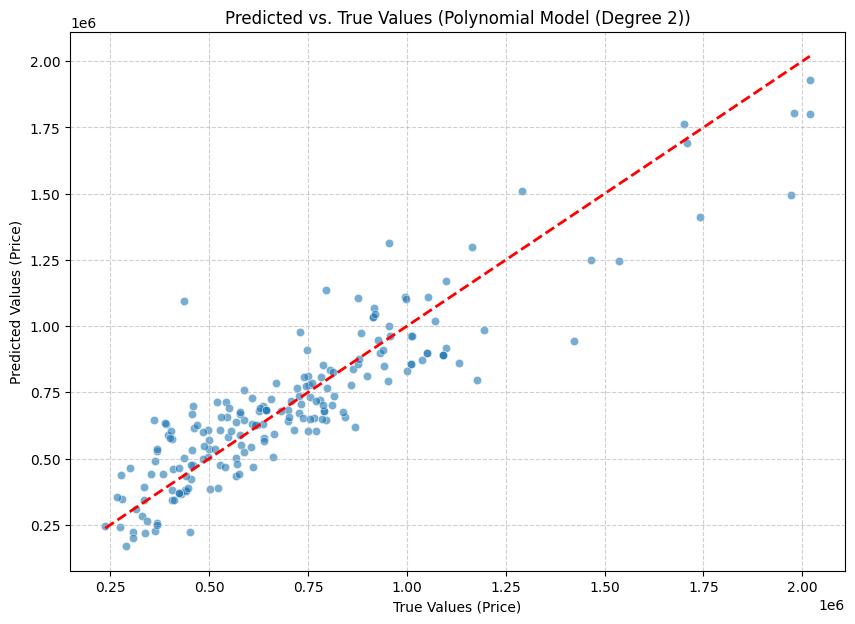


Observation: If the points roughly line up along the diagonal, it indicates a good fit where predicted values are close to true values. Deviations show model errors.


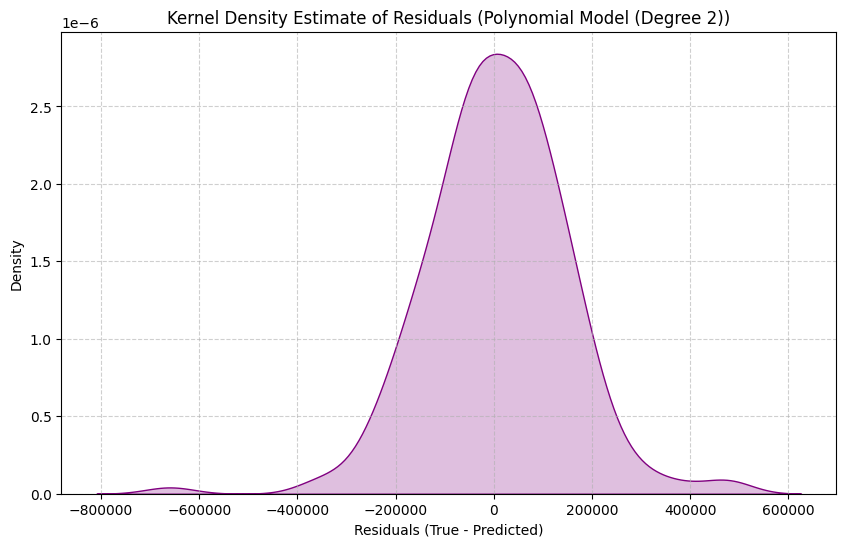


Observation: Ideally, residuals should be bell-shaped (normally distributed) around zero. Skewness or multiple peaks suggest that the model might be missing important variables or that the assumptions of linear regression are violated.

--- Strengths and Weaknesses of the Model ---
Strengths:
- Provides a quantifiable measure of how different features contribute to car price.
- Interpretability of coefficients (especially in the linear parts) helps understand feature impact.
- Handles both numerical and categorical data effectively with one-hot encoding.

Weaknesses:
- The R^2 values are relatively low, indicating that a large portion of the variance in car prices is not explained by the included features.
- Residual plots may show non-normality or heteroscedasticity, suggesting that linear assumptions might not fully hold or there are uncaptured non-linear relationships.
- Polynomial expansion improved the model but still showed limitations, possibly overfitting or not capturing comp

In [21]:
# Use the best model (either combined from Q3.4 or polynomial from Q3.5)
# For simplicity, let's assume 'best_y_pred' from Q3.5 loop holds the best prediction.
# If degree 1 was best, best_y_pred would be from the linear model with polynomial features of degree 1.
# If the combined model from Q3.4 was actually better, we'd use y_test_pred_combined.

# Let's explicitly define the 'best model' for plotting based on the comparison in Q3.5
if best_r2 > r2_test_combined:
    final_y_pred = best_y_pred
    model_description = f"Polynomial Model (Degree {best_degree})"
else:
    final_y_pred = y_test_pred_combined
    model_description = "Combined Model (Q3.4)"

print(f"\n--- Analysis of the Best Model: {model_description} ---")

# Plot predicted values against true values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=final_y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.title(f'Predicted vs. True Values ({model_description})')
plt.xlabel('True Values (Price)')
plt.ylabel('Predicted Values (Price)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nObservation: If the points roughly line up along the diagonal, it indicates a good fit where predicted values are close to true values. Deviations show model errors.")

# Compute residuals
residuals = y_test - final_y_pred

# Create a kernel density plot of the residuals
plt.figure(figsize=(10, 6))
sns.kdeplot(residuals, fill=True, color='purple')
plt.title(f'Kernel Density Estimate of Residuals ({model_description})')
plt.xlabel('Residuals (True - Predicted)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nObservation: Ideally, residuals should be bell-shaped (normally distributed) around zero. Skewness or multiple peaks suggest that the model might be missing important variables or that the assumptions of linear regression are violated.")

print("\n--- Strengths and Weaknesses of the Model ---")
print("Strengths:")
print("- Provides a quantifiable measure of how different features contribute to car price.")
print("- Interpretability of coefficients (especially in the linear parts) helps understand feature impact.")
print("- Handles both numerical and categorical data effectively with one-hot encoding.")

print("\nWeaknesses:")
print("- The R^2 values are relatively low, indicating that a large portion of the variance in car prices is not explained by the included features.")
print("- Residual plots may show non-normality or heteroscedasticity, suggesting that linear assumptions might not fully hold or there are uncaptured non-linear relationships.")
print("- Polynomial expansion improved the model but still showed limitations, possibly overfitting or not capturing complex interactions beyond simple polynomial terms.")
print("- Potential for multicollinearity, especially with polynomial features, which can make coefficient interpretation difficult.")
print("- Outliers in price data can heavily influence the model (as seen in the wide spread of prices). A log transformation of price might be more appropriate but was not used for the final models in this section for direct comparison with raw price.")

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

### Q4.1: Write down the SSE for this model.

The model is given by:
$$ \hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2} $$
The Sum of Squared Errors (SSE) is:
$$ SSE = \sum_{i=1}^N (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2})^2 $$

### Q4.2: Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.

Set partial derivatives of SSE to zero:

1.  **With respect to $b_0$:**
    $$ \frac{\partial SSE}{\partial b_0} = -2 \sum_{i=1}^N (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0 $$
    $$ \sum_{i=1}^N (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0 \quad \text{(Equation 1)} $$

2.  **With respect to $b_1$:**
    $$ \frac{\partial SSE}{\partial b_1} = -2 \sum_{i=1}^N z_{i1} (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0 $$
    $$ \sum_{i=1}^N z_{i1} (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0 \quad \text{(Equation 2)} $$

3.  **With respect to $b_2$:**
    $$ \frac{\partial SSE}{\partial b_2} = -2 \sum_{i=1}^N z_{i2} (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0 $$
    $$ \sum_{i=1}^N z_{i2} (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}) = 0 \quad \text{(Equation 3)} $$

### Q4.3: Verify that the average error is zero and $e \cdot z =0$ at the optimum.

From Equation 1:
$$ \sum_{i=1}^N e_i = 0 \implies \text{Average error is zero.} $$

From Equation 2:
$$ \sum_{i=1}^N z_{i1} e_i = 0 \implies \text{Errors are orthogonal to } z_1. $$

From Equation 3:
$$ \sum_{i=1}^N z_{i2} e_i = 0 \implies \text{Errors are orthogonal to } z_2. $$

In vector notation, $e \cdot z = 0$ means the error vector $e$ is orthogonal to the predictor vectors $z_1$ and $z_2$, a fundamental OLS property.

### Q4.4: Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.

From Equation 1, and knowing $z_{i1}$ and $z_{i2}$ are centered (i.e., $\sum z_{i1} = 0, \sum z_{i2} = 0$):
$$ \sum y_i - N b_0 - b_1 \sum z_{i1} - b_2 \sum z_{i2} = 0 $$
$$ \sum y_i - N b_0 = 0 \implies b_0^* = \frac{\sum y_i}{N} = \bar{y} $$

Substitute $b_0^* = \bar{y}$ into Equation 2 and Equation 3. Since $(y_i - \bar{y})$ is equivalent to $y_i$ when terms are multiplied by centered variables, and $\sum z_{ij}(y_i - \bar{y}) = \sum z_{ij}y_i$:

**Equation A (from Eq 2):**
$$ b_1 \sum z_{i1}^2 + b_2 \sum z_{i1} z_{i2} = \sum z_{i1} y_i $$

**Equation B (from Eq 3):**
$$ b_1 \sum z_{i1} z_{i2} + b_2 \sum z_{i2}^2 = \sum z_{i2} y_i $$

### Q4.5: Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.

The system of equations (A and B) can be written in matrix form as $Ab=C$, where:

$$ A = \begin{pmatrix}
\sum z_{i1}^2 & \sum z_{i1} z_{i2} \\
\sum z_{i1} z_{i2} & \sum z_{i2}^2
\end{pmatrix} $$

$$ b = \begin{pmatrix}
b_1 \\
b_2
\end{pmatrix} $$

$$ C = \begin{pmatrix}
\sum z_{i1} y_i \\
\sum z_{i2} y_i
\end{pmatrix} $$

### Q4.6: Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

Dividing both sides by $N$, the matrix equation becomes $A'b = C'$, where:

**Matrix A' becomes the covariance matrix of the independent variables:**
$$ A' = \begin{pmatrix}
\text{Var}(x_1) & \text{Cov}(x_1, x_2) \\
\text{Cov}(x_1, x_2) & \text{Var}(x_2)
\end{pmatrix} $$

**Vector C' becomes the covariance vector between the independent variables and the dependent variable:**
$$ C' = \begin{pmatrix}
\text{Cov}(x_1, y) \\
\text{Cov}(x_2, y)
\end{pmatrix} $$

**Intuition:**

1.  **Dependence on Covariances:** OLS coefficients ($b_1, b_2$) are determined by the variances and covariances of the independent variables and their covariances with the dependent variable. Centering the data simplifies this, isolating these relationships.

2.  **Multicollinearity Insight:** The covariance matrix $A'$ highlights multicollinearity. High correlation between predictors (large $Cov(x_1, x_2)$) makes $A'$ near-singular, leading to unstable coefficient estimates.

3.  **Predictor-Response Relationship:** Vector $C'$ shows that coefficients are influenced by how each predictor covaries with the response $y$. Stronger covariance indicates a stronger relationship captured by the model.